# Random Signal

- Jose Gonzalez Lopez

- Mykola Liashuha

# Imports

In [1]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise

from scipy.io import wavfile #Read wavfiles
from scipy.signal import periodogram,welch #Get periodograms
from scipy.fft import fft, fft2,ifft,ifft2, fftfreq #Fourier transform


# Introduction
This notebook will perform a noise spectral analysis of audio and image files. The main objective will be to play with different situations and understand what random signals can actually do to the data itself. In order to process these signals and comprehend them we will first perform a basic analysis to 3 noise files and identify them. Then, we will do some image and audio noising and denoising. In the end we will draw our conclusions of the project.

# Auxiliar functions

In [2]:
'''
This fuction plots the fourier transform of an audio file
'''

def plot_fourier_transform(data, samplerate):
    N = data.shape[0]
    # sample spacing
    T = 1.0 / samplerate
    #Transform
    yf = fft(data)
    xf = fftfreq(N, T)[:N//10]
    #And plot
    plt.figure(figsize=(10,10))
    plt.xlabel('Freq (Hz)')
    plt.ylabel('FFT')
    plt.plot(xf, np.abs(yf)[:N//10])
    plt.show()

In [3]:
'''
This functin plots the periodogram of an audio file in the log scale
'''

def plot_periodogram(data,samplerate):
    #Get frecuency and estimate power spectrum
    f, P_den = periodogram(data, samplerate)
    
    #Clean the result, get positive values
    P_den = abs(P_den)**2
    P_den = P_den / sum(P_den)

    #Plot in logarithmic scale
    plt.semilogy(f, P_den)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
    plt.show()

In [4]:
'''
This function plots the welch method of an audio file in the log scale
'''

def plot_welch(data,samplerate):
    #Get frecuency and estimate power spectrum
    f, P_den = welch(data, samplerate)
    
    #Clean the result, get positive values
    P_den = abs(P_den)**2
    P_den = P_den / sum(P_den)

    #Plot in logarithmic scale
    plt.semilogy(f, P_den)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
    plt.show()

In [23]:
'''
Signal-to-noise ratio
x: original signal
y: changed(noisy) signal
'''
def snr(x, y):
    
    return 20*np.log10(np.sqrt(np.power(x, 2).sum())/np.sqrt(np.power(x-y, 2).sum()))

In [6]:
'''
Weiner denoising algorith
img_noise: noisy image,
std: sigma of guassian noise
'''
def weiner_denoise(img_noise, std):
    P = (1/(img_noise.shape[0]*img_noise.shape[1])) * np.power(np.abs(fft2(img_noise)), 2)
    h_w = np.real(ifft2( P / ( P + np.power(std, 2) ) ))
    res = np.real(ifft2(fft2(img_noise) *fft2(h_w)))
    return res

# 1. Noise analysis
In this section we will analyse the noise files given for this exercise. We will start each analysis by doing the Fourier Transform of the noise, then we will get the periodogram and last we will discover which noise is each of them.

## Noise 1 

Let's just do a little experiment by ploting the fourier transform of the noise and see what happens.

In [7]:
samplerate_1, data_1 = wavfile.read("noise1.wav") #Read the file
ipd.Audio(data_1, rate=samplerate_1)

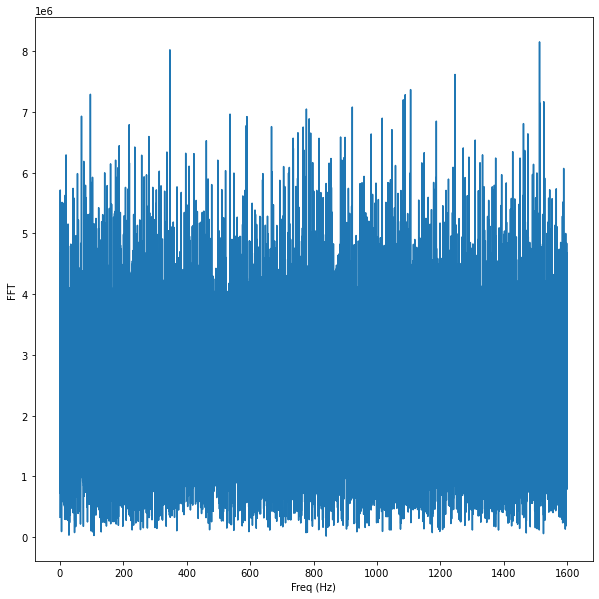

In [8]:
plot_fourier_transform(data_1, samplerate_1)

In the image above, the fourier transform cannot tell us any infomation about the signal because its plot is a total mess. This means that we are dealing with noise, a random signal. So, to actually analyse this data, we have to get its power spectrum (approximately) using the periodogram method and the welch procedure. 

### Periodogram

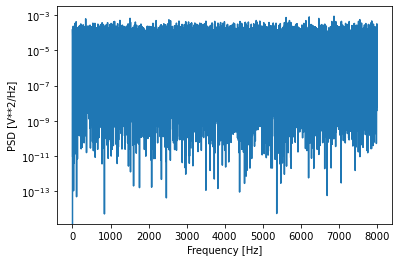

In [9]:
plot_periodogram(data_1,samplerate_1)

### Welch method

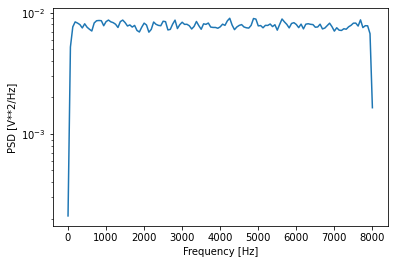

In [10]:
plot_welch(data_1,samplerate_1)

### Color identification

If we look at both images, the power spetrum seems to be stable during the whole audio, so this noise is behaving as a **white** noise. [1]

## Noise 2

We will reapeat the same experiment by ploting the fourier transform of the noise.

In [11]:
samplerate_2, data_2 = wavfile.read("noise2.wav") #Read the file
ipd.Audio(data_2, rate=samplerate_2)

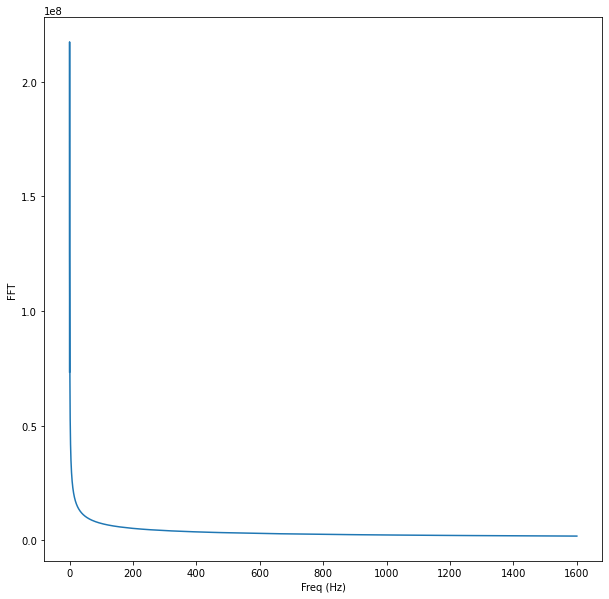

In [12]:
plot_fourier_transform(data_2, samplerate_2)

In this case, we have the opposite case than the last one. Seems that the Fourier Transform did not get any information at all, which in our opinion reflects the same effect as a random signal would do: not be certain about the signal. In this case, we have the opposite case than the last one. We have to get its power spectrum (approximately) using the periodogram method and the welch procedure.

### Periodogram

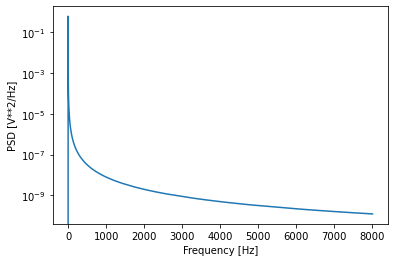

In [13]:
plot_periodogram(data_2,samplerate_2)

### Welch method

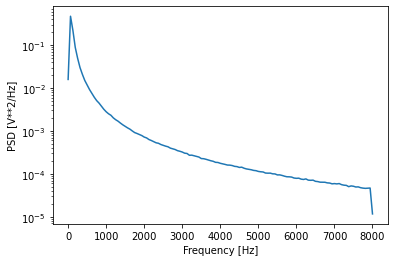

In [14]:
plot_welch(data_2,samplerate_2)

### Color identification

If we look at both images, the power spetrum seems to be decreasing during the whole audio, so this noise is behaving as a **pink** noise. [1]

## Noise 3

We will reapeat the same experiment by ploting the fourier transform of the noise.

In [15]:
samplerate_3, data_3 = wavfile.read("noise3.wav") #Read the file
ipd.Audio(data_3, rate=samplerate_3)

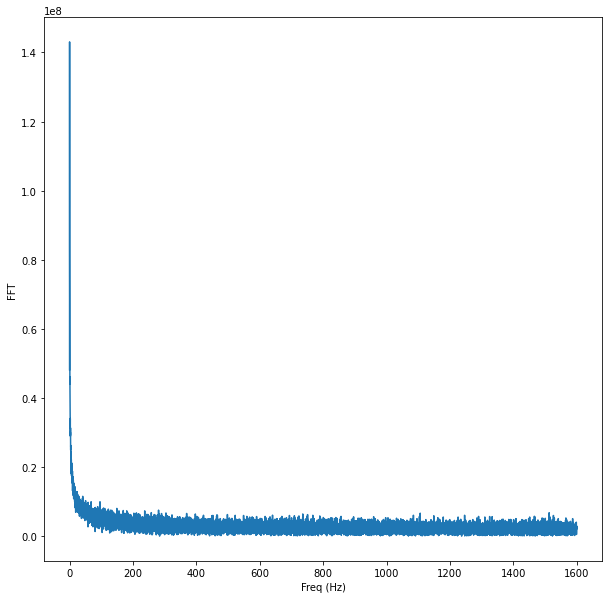

In [16]:
plot_fourier_transform(data_3,samplerate_3)

We are having the same trouble as the examples above. The Fourier Transform is messy again but intuitively we can already see *some* patterns of repetition with the already analyzed noises. We will do the same drill.

### Periodogram

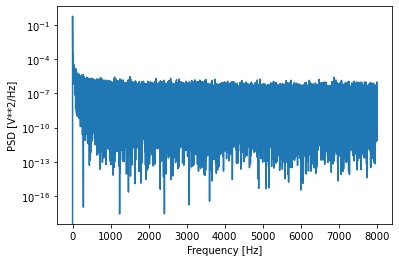

In [17]:
plot_periodogram(data_3,samplerate_3)

### Welch method

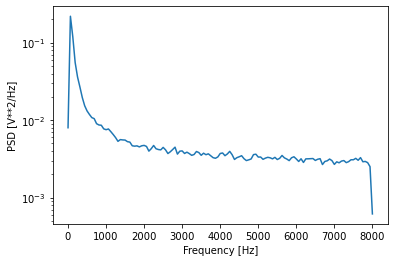

In [18]:
plot_welch(data_3,samplerate_3)

### Color identification

Looking at both images, the power spetrum seems to decrease at first but then it stabilized in the end. We can suposse that this noise is a mix of **pink** and **white** noises. [1]

# 2. Image noising and denoising

Below we are going to present the way of applying noise to an image and afterwards denoising it with weiner filter.

First step is to read an original image (barbara.jpg)

In [19]:
img = cv2.imread('barbara.jpg',0) #Reading
height,width = img.shape #Getting essential features of image

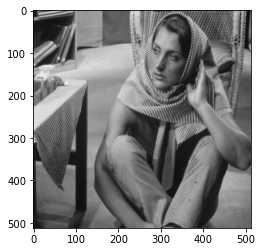

In [20]:
plt.imshow(img,cmap='gray')

Further we are going to apply some additional noise in this way:
$$y = x + sigma * generated\_normal\_samples$$


In [24]:
std = 0.08
noise = numpy.random.normal(0, 1, size=img.shape)

img_noise = img + std*noise

Below here is an example of SNR measurement. Signal-to-noise ratio displays how much noise we have in the signal basically by comparing desired signal with noise levels we have in the signal. SNR is computed in this way:
$$SNR(y∣x)=20*log( \frac{∥x∥}{∥x-y∥}) \\
where\ x\ is\ original\ signal,\ y\ is\ noisy\ signal\ and\ ∥\ is\ absolute\ norm\ (1st\ Norm)$$

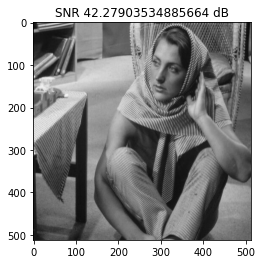

In [25]:
plt.imshow(img_noise,cmap='gray')
plt.title(f'SNR {snr(img,img_noise)} dB')
plt.show()

Below we are going to provide results of denosing images with applyig different levels of noise: 0, 5, 15 and 20 dB. In this case we are using Weiner filter to denoise the image.

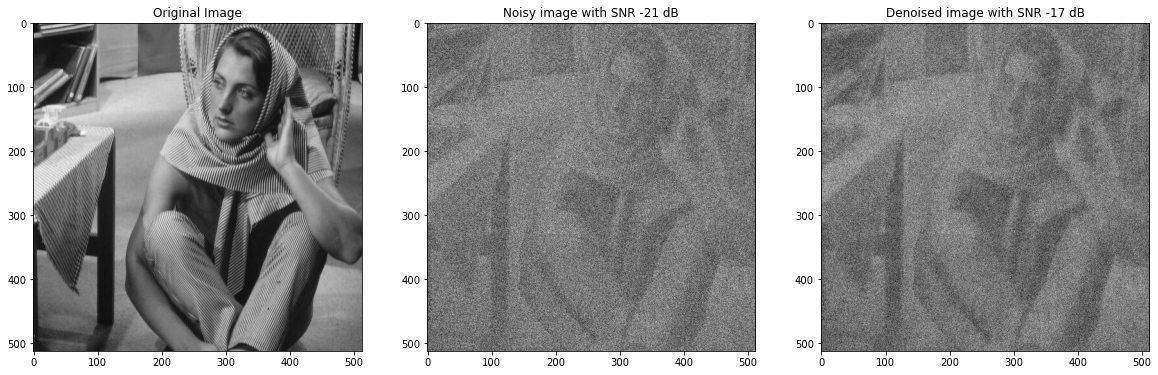

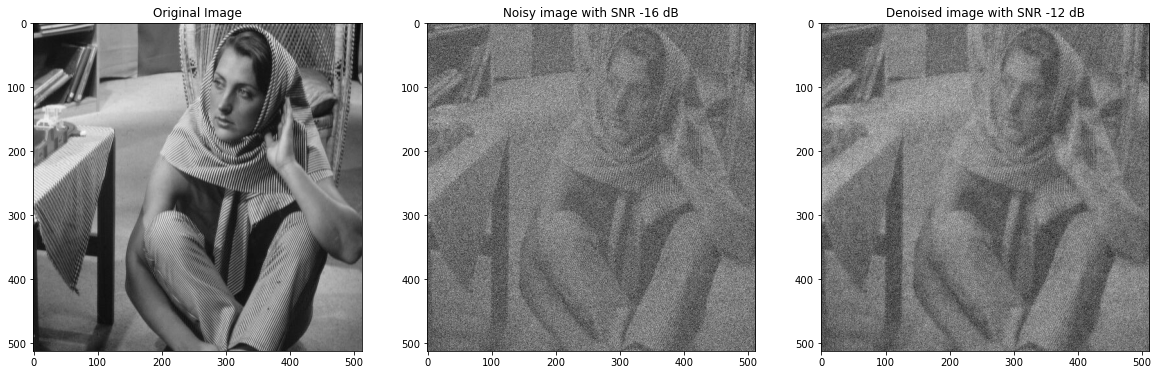

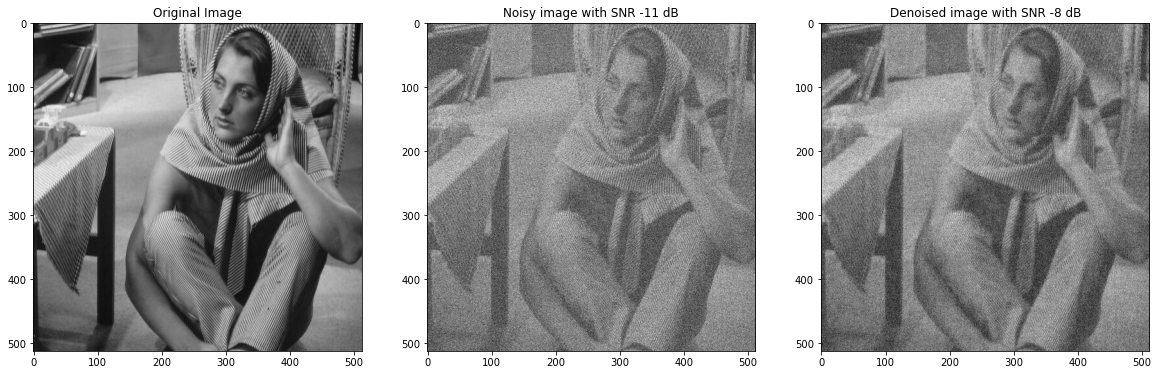

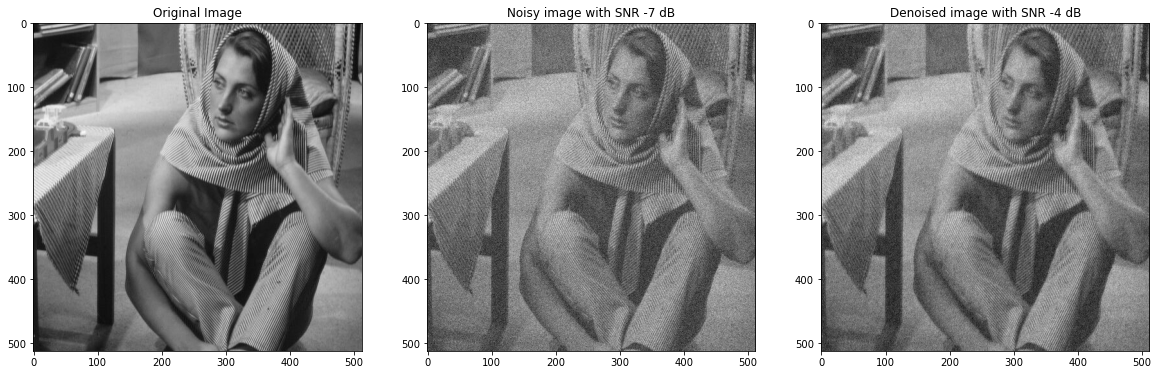

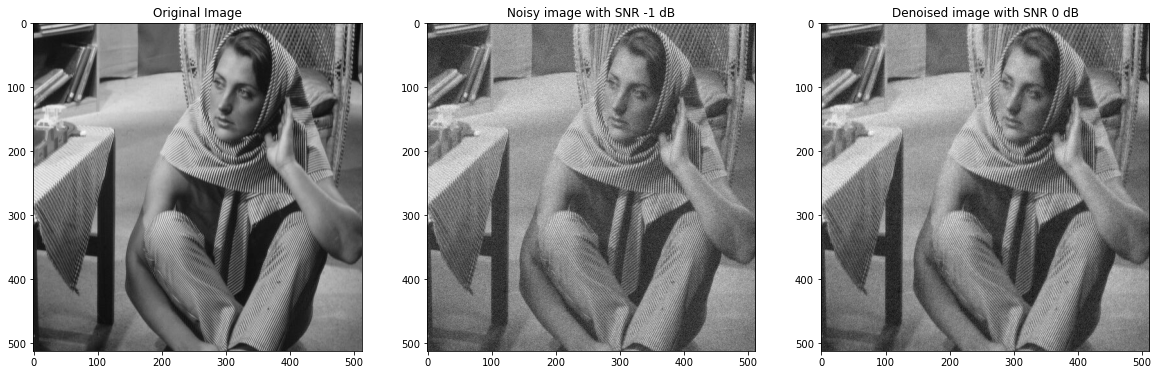

In [26]:
stds = [130,70,40, 24,13]
for std in stds:
#     std = 13
    noise = numpy.random.normal(0, 1, size=img.shape)

    img_noise = img + std*noise

    fig, axs = plt.subplots(1, 3)
    fig.set_figheight(20)
    fig.set_figwidth(20)
    axs[0].imshow(img,cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].imshow(img_noise,cmap='gray')
    axs[1].set_title('Noisy image'+f' with SNR {int(snr(img,img_noise))} dB')
    denoised = weiner_denoise(img_noise, std)
    axs[2].imshow(denoised,cmap='gray')
    axs[2].set_title('Denoised image'+f' with SNR {int(snr(img,denoised))} dB')
    plt.show()

Overall, it was prooved that we managed to add Gaussian white noise to the image. And moreover, Weiner filter denoised our image since we meaasured the SNR value before and after denoising. And after denosing noisy image, the SNR measurements increased which means that in denoised image there appears more signal than noise comparing to noisy image (before denoising).

# 3. Music noising and denoising

In this excersise we will adding noise to a music file and denoise it by appling the Wiener filter. Let's hear first the audio file.

In [24]:
samplerate_music, data_music = wavfile.read("music.wav") #Read the file
ipd.Audio(data_music, rate=samplerate_music)

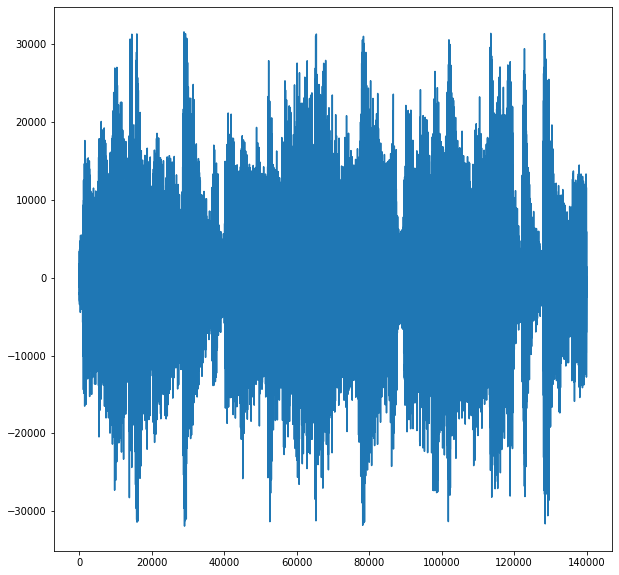

In [25]:
plt.figure(figsize=(10,10))
plt.plot(data_music)

The music seems perfectly clean and the melody is recognizable. We will just plot the fourier transform to make the analysis more complete.

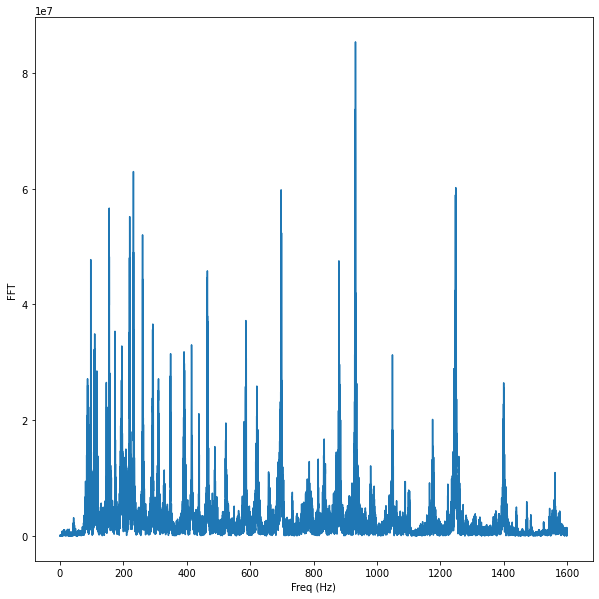

In [26]:
plot_fourier_transform(data_music,samplerate_music)

As the melody is quite complex, it is normal to have a lot of peaks in different frequencies. We will add the first noise with a 0.1 ratio to mix things a little bit.

In [27]:
noisy_data_music=data_music+0.1*(data_1)
ipd.Audio(noisy_data_music, rate=samplerate_music)

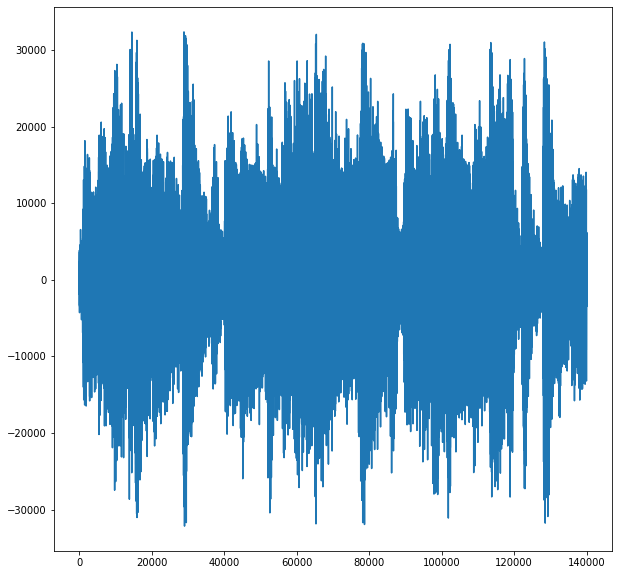

In [28]:
plt.figure(figsize=(10,10))
plt.plot(noisy_data_music)

Althought we can still hear the music, the buzz of the noise is actually quite annoying. We should get rid of it.

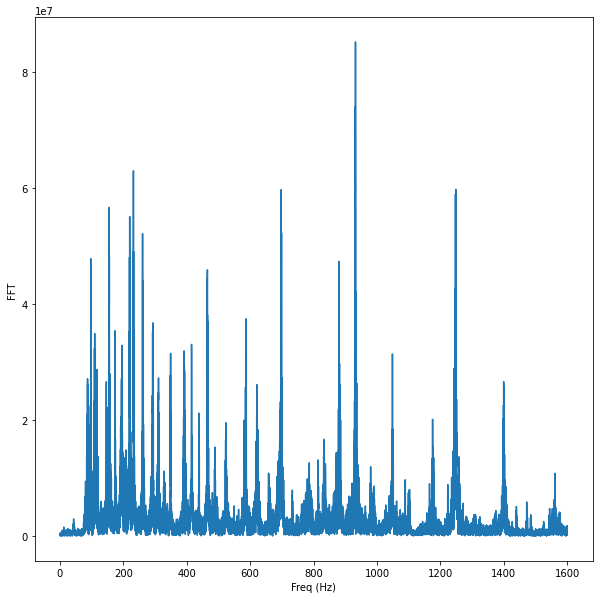

In [29]:
plot_fourier_transform(noisy_data_music,samplerate_music)

We will use the Wiener filter as done in the previous section.

$\hat{h}[k]=\cfrac{E(|\hat{x}[k]|^{2})}{E(|\hat{x}[k]|^{2})+E(|\hat{n}[k]|^{2})}$

Where $h$ is the filter, $x$ the orginal audio and $n$ the noisy version.

In [30]:
N = data_music.shape[0]
N_2 = noisy_data_music.shape[0]
P = 1/N * np.abs(fft(data_music))**2 #Power of the original signal
P_2=1/N_2 * np.abs(fft(noisy_data_music))**2 #Power of noisy signal
h_w = np.real(ifft(P/(P+P_2))) #Get filter
wiener=np.real(ifft((fft(noisy_data_music)*fft(h_w)))) #Apply filter

In [31]:
ipd.Audio(wiener, rate=samplerate_music)

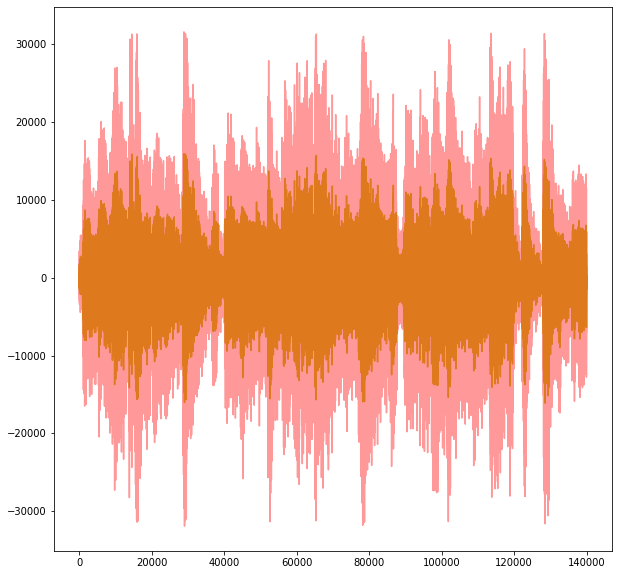

In [32]:
plt.figure(figsize=(10,10))
plt.plot(wiener,alpha=0.8,c='y')
plt.plot(data_music,alpha=0.4,c='r')
plt.show()

And we can see that the noisy was succesfully removed but the volume has been reduced by half.

# Conclusion

In this lab exercise we have implemented several approaches to signal denoising. We have got experience how to artifically add noise to the singla. With the output results from denoising algorthms we have proven that it is possible to identify noise in the signal and separate it in order to get the original (clean) one. 

# References
[1] [Colors of noise - Wikipedia](https://en.wikipedia.org/wiki/Colors_of_noise)

[2] [Examples of image denoising algortihms in Matlab](https://nbviewer.org/github/gpeyre/numerical-tours/blob/master/matlab/denoisingsimp_2b_linear_image.ipynb)

[2] [Examples of signal denoising algortihms in Matlab](https://nbviewer.org/github/gpeyre/numerical-tours/blob/master/matlab/denoisingsimp_2_linear.ipynb)